# P2.9 · Residual additions

**Maths fundamentals for transformers · Tiny Transformer**

The model combines a direct path with a transformed path while keeping the same feature width.

**You will be able to:** A residual branch returns an update with the same shape as its input; adding them provides a direct computational path.

This notebook runs independently in Jupyter or Google Colab on a CPU. Download it from the course, then use **Colab → File → Upload notebook**. Public publication target: https://github.com/gkiri/tiny_repo. All required numerical examples are included.

The model connection uses the same **9,417-parameter transformer** as Unit 1: 65 characters, 32 positions, 28 features, two heads, learned position embeddings, LayerNorm and GELU.

In [1]:
#@title Setup: CPU, local Jupyter or Google Colab { display-mode: "form" }
# This notebook is self-contained. No account, secret, repository clone or GPU is required.
import sys, math, json, base64, zlib, hashlib
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(7)
torch.set_num_threads(1)
plt.rcParams.update({"figure.figsize": (7, 3), "figure.dpi": 100, "axes.spines.top": False,
                     "axes.spines.right": False, "axes.grid": True, "grid.alpha": .18})
print("Ready on CPU · PyTorch", torch.__version__)
print("All example data is included in this notebook.")

Ready on CPU · PyTorch 2.10.0+cpu
All example data is included in this notebook.


## Predict first

Why add an update to the existing vector?

Write down your prediction before running the calculation.

If x = [2, 0, 1] and the update is [0, 0, 0], what is the output?

## Work the numbers

1. Keep input x = [2, 0, 1] on the direct path

2. Branch update Δ = [−1, 1, 0]

3. Add coordinate by coordinate → [1, 1, 1]

4. Zero update leaves x; opposite update can cancel x

$$x_1=x_0+\operatorname{Attn}(\operatorname{LN}_1(x_0)),\quad x_2=x_1+\operatorname{FF}(\operatorname{LN}_2(x_1))$$

These small numbers are **Illustrative**. Each symbol names a quantity already shown above.

In [2]:
#@title Explicit teaching functions (expand to inspect) { display-mode: "form" }
"""P2's explicit calculations. Each function is checked against an independent PyTorch operation.

Rows use the final axis for features. Linear weights use PyTorch's [out, in] convention.
These readable implementations teach the operations; the reference model remains unchanged.
"""
import math
import torch


def dot(x, y):
    if x.shape != y.shape or x.ndim != 1:
        raise ValueError("dot needs two vectors of the same length")
    return (x * y).sum()


def linear(x, weight, bias):
    return x @ weight.transpose(-2, -1) + bias


def embeddings(ids, token_table, position_table):
    positions = torch.arange(ids.shape[-1], device=ids.device)
    if ids.shape[-1] > position_table.shape[0]:
        raise ValueError("the position table is shorter than the input")
    return token_table[ids] + position_table[positions]


def layernorm(x, gamma, beta, eps=1e-5):
    mean = x.mean(dim=-1, keepdim=True)
    variance = ((x - mean) ** 2).mean(dim=-1, keepdim=True)
    return (x - mean) / torch.sqrt(variance + eps) * gamma + beta


def softmax(scores, temperature=1.0):
    if temperature <= 0 or not math.isfinite(temperature):
        raise ValueError("temperature must be finite and positive")
    if torch.isnan(scores).any() or torch.isposinf(scores).any() or torch.isneginf(scores).all(dim=-1).any():
        raise ValueError("each score row needs a finite entry, with no NaN or positive infinity")
    scaled = scores / temperature
    shifted = scaled - scaled.max(dim=-1, keepdim=True).values
    positive = torch.exp(shifted)
    return positive / positive.sum(dim=-1, keepdim=True)


def attention(q, k, v):
    scores = q @ k.transpose(-2, -1) / math.sqrt(q.shape[-1])
    allowed = torch.ones(scores.shape[-2:], dtype=torch.bool, device=q.device).tril()
    masked = scores.masked_fill(~allowed, float("-inf"))
    shares = softmax(masked)
    return shares @ v, shares, masked


def gelu(x):
    cdf = 0.5 * (1 + torch.erf(x / math.sqrt(2)))
    return x * cdf


def residual(x, update):
    if x.shape != update.shape:
        raise ValueError("a residual update must have the same shape as its input")
    return x + update


def cross_entropy(logits, targets):
    log_prob = logits - torch.logsumexp(logits, dim=-1, keepdim=True)
    correct = log_prob.gather(-1, targets.unsqueeze(-1)).squeeze(-1)
    return -correct.mean()


def tiny_loss(w):
    """One adjustable logit: target 0, logits [2*w, 1, 0]."""
    z = torch.stack((2 * w, torch.ones_like(w), torch.zeros_like(w)))
    return cross_entropy(z.unsqueeze(0), torch.tensor([0], device=w.device))


def finite_difference(f, x, step=1e-5):
    return (f(x + step) - f(x - step)) / (2 * step)


def adamw_step(parameter, gradient, first, second, step, lr=0.003,
               betas=(0.9, 0.999), eps=1e-8, weight_decay=0.01):
    """One AdamW update, including moment bias correction and decoupled weight decay."""
    beta1, beta2 = betas
    first = beta1 * first + (1 - beta1) * gradient
    second = beta2 * second + (1 - beta2) * gradient.square()
    first_hat = first / (1 - beta1 ** step)
    second_hat = second / (1 - beta2 ** step)
    parameter = parameter * (1 - lr * weight_decay) - lr * first_hat / (second_hat.sqrt() + eps)
    return parameter, first, second

print("Explicit functions loaded; each is independently tested against PyTorch.")

Explicit functions loaded; each is independently tested against PyTorch.


## Implement and verify

Read each line, predict its output, then run it. The explicit calculation and the PyTorch operation should agree.

In [3]:
x = torch.tensor([2., 0., 1.])
update = torch.tensor([-1., 1., 0.])
print("residual", (x + update).tolist())
print("zero update", (x + torch.zeros_like(x)).tolist())
print("cancellation", (x + -x).tolist())
s = torch.tensor(2., requires_grad=True)
y = s + s.square()
y.backward()
print("two gradient paths", s.grad.item())

residual [1.0, 1.0, 1.0]
zero update [2.0, 0.0, 1.0]
cancellation [0.0, 0.0, 0.0]
two gradient paths 5.0


## See it and change one thing

The plot is generated by the code. Change one input and predict how the picture will change before running it again.

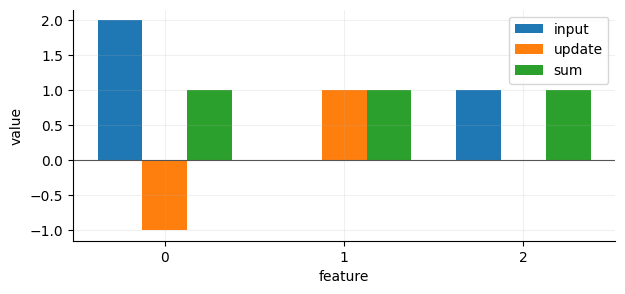

In [4]:
x=np.array([2.,0.,1.]);d=np.array([-1.,1.,0.]);i=np.arange(3)
for shift,y,label in [(-.25,x,"input"),(0,d,"update"),(.25,x+d,"sum")]:plt.bar(i+shift,y,.25,label=label)
plt.axhline(0,color="#555",lw=.8);plt.xticks(i);plt.xlabel("feature");plt.ylabel("value");plt.legend();plt.show()

## Find it in the transformer

The following values were exported at full precision from the pinned Unit 1 checkpoint. Crops are for display; complete vectors are used in calculations.

Recorded input: `You taught me language; and my p`.

Reference lesson: **inside-feed-forward**.

In [5]:
#@title Recorded model fixture (included; no download) { display-mode: "form" }
recorded = json.loads('{"x0":[[0.5288646221160889,-0.8432598114013672,-0.5695772171020508,-1.0559104681015015,-1.4223241806030273,-0.22870169579982758,0.888141393661499,-0.6670805215835571,-0.3276605010032654,-1.0255589485168457,0.11964564025402069,1.055565357208252,0.7501133680343628,0.010415524244308472,-0.141560360789299,0.08990059792995453,-0.5610997676849365,-0.3371422290802002,-0.2847738564014435,0.3079955577850342,-0.19202598929405212,-0.2562892735004425,-1.011565923690796,-0.4321156144142151,0.17623043060302734,-0.8135979771614075,0.79559326171875,-0.12354907393455505],[-0.5065473318099976,0.3310849368572235,0.3844981789588928,-0.04370655119419098,-0.5256234407424927,0.27010512351989746,0.4063345193862915,0.37468940019607544,-0.183644101023674,-0.6681257486343384,-0.12708620727062225,-0.053157612681388855,0.003068310208618641,-0.11830690503120422,-0.32301536202430725,0.23759160935878754,-0.8140854239463806,-0.5494789481163025,-0.11406159400939941,0.24433156847953796,-0.40040892362594604,-0.9795957207679749,-0.1685928851366043,-0.6898574233055115,0.9124152064323425,-0.2856059670448303,0.8179931640625,0.7574946880340576],[-0.6532999277114868,-0.01288018748164177,0.05106845125555992,0.4490329623222351,0.567115843296051,0.9053878784179688,0.3035985231399536,0.14798882603645325,-0.6512718200683594,-0.7640279531478882,-0.019388971850275993,-0.21573762595653534,-0.2800464332103729,-0.19147923588752747,-0.40719595551490784,-0.5717101693153381,-0.09194251149892807,-0.3815131187438965,0.482538104057312,-0.5558981895446777,-0.5140880346298218,-0.15208804607391357,-0.28163185715675354,0.12739227712154388,0.6260901093482971,-0.9428892135620117,0.6893051266670227,0.20302365720272064],[0.08901157975196838,0.040529437363147736,0.6848146915435791,0.6300724148750305,-0.566245973110199,-0.17726761102676392,0.47558432817459106,0.49766653776168823,0.02257472276687622,0.4593220055103302,0.3417660593986511,-0.970190167427063,0.2272055447101593,0.022357359528541565,-0.28768691420555115,0.46897661685943604,-0.009488478302955627,-0.23293352127075195,0.5518352389335632,-0.08896376937627792,-0.5263469219207764,-0.3299548625946045,-0.6215490698814392,-0.4103282392024994,0.4982185661792755,-0.7472269535064697,0.5580591559410095,-0.7769008278846741],[-0.9307531118392944,0.39697524905204773,-0.01426272839307785,0.5215244293212891,0.377559095621109,-0.8952552676200867,0.10714805126190186,-0.37945815920829773,0.6382444500923157,-0.06333956867456436,0.1537887156009674,-0.3071882724761963,0.5669894218444824,0.03541810065507889,-0.3740121126174927,0.19983166456222534,-0.48323556780815125,-0.6460843086242676,0.49971652030944824,0.3096412122249603,-0.447502464056015,-0.5301752090454102,-0.5094863772392273,0.01547519862651825,0.21868658065795898,-0.8263669013977051,0.6307337284088135,0.1906687319278717],[-0.4075401723384857,0.12483622133731842,-0.2795301675796509,-0.6465123295783997,-0.26301684975624084,-0.016257397830486298,0.4962344765663147,0.9660438299179077,-0.4785956144332886,-0.5344048738479614,0.46942538022994995,-1.1615495681762695,-0.02202482894062996,-0.21309331059455872,-0.2913011908531189,0.10030579566955566,-0.5138093829154968,-0.5647326111793518,0.2478710263967514,0.09108695387840271,-0.3394824266433716,-0.7527979016304016,0.5092169046401978,0.28718888759613037,0.21684008836746216,-0.5863174796104431,0.39974671602249146,0.2421642541885376],[-0.643967866897583,-0.004038993269205093,0.046385642141103745,0.4343241751194,0.6180112957954407,0.9116613268852234,0.11341594159603119,0.17389294505119324,-0.6555492877960205,-0.7722946405410767,-0.019506393000483513,-0.25406163930892944,-0.22818416357040405,-0.16715629398822784,-0.2995968759059906,-0.5522958636283875,-0.07717230170965195,-0.39107435941696167,0.4746713936328888,-0.5153945088386536,-0.4287658929824829,-0.15513013303279877,-0.273040235042572,0.12281370162963867,0.6826963424682617,-0.9847966432571411,0.49484121799468994,0.22718219459056854],[-0.649269700050354,0.6851776838302612,0.27197712659835815,-0.27171826362609863,0.30333203077316284,-0.2733616530895233,0.2280360460281372,0.30233538150787354,0.3869776725769043,-0.3579525351524353,-0.45445945858955383,-0.3792523145675659,-0.02747400850057602,-0.48972219228744507,-0.5828709006309509,0.5203595161437988,0.27139490842819214,0.5064595937728882,-0.11780519783496857,-0.3730149269104004,0.003921762108802795,-0.017229892313480377,0.16443021595478058,-0.28269344568252563,0.9785215854644775,-1.1068626642227173,0.2687433362007141,-0.6564116477966309],[-0.6334052085876465,0.022086765617132187,0.41210561990737915,-0.5379233360290527,0.06954365968704224,-1.0539524555206299,0.25122159719467163,0.8653014898300171,-0.47473058104515076,-0.35462188720703125,-0.45758944749832153,0.17816868424415588,-0.021869167685508728,0.00602436438202858,-0.3083364963531494,0.516846776008606,0.11735136806964874,0.0529121458530426,0.11036977171897888,-0.18978744745254517,-0.5467442274093628,0.2623445391654968,-0.6904827356338501,-0.18371358513832092,0.9636837244033813,-0.2626807987689972,0.23862141370773315,0.5513636469841003],[-0.9215596914291382,0.41157400608062744,0.020755399018526077,0.5319675803184509,0.43598607182502747,-0.8823927044868469,-0.08486957848072052,-0.3268965780735016,0.6400405168533325,-0.06432407349348068,0.16775692999362946,-0.3174441158771515,0.6281507611274719,0.091030053794384,-0.2159748375415802,0.21684417128562927,-0.4536252021789551,-0.6254377961158752,0.5031116008758545,0.36777472496032715,-0.3596993684768677,-0.524132490158081,-0.48540782928466797,0.025678694248199463,0.28207820653915405,-0.8614091277122498,0.41286271810531616,0.22578221559524536],[0.10000821948051453,0.06676413118839264,0.7209221124649048,0.6448160409927368,-0.4769299030303955,-0.1645979881286621,0.2041803002357483,0.5725901126861572,0.027159668505191803,0.46095314621925354,0.35373327136039734,-0.988184928894043,0.3202664256095886,0.09184245765209198,-0.07254484295845032,0.491613507270813,0.01595093309879303,-0.20579789578914642,0.5560194849967957,-0.008305234834551811,-0.39663103222846985,-0.3203105926513672,-0.5858294367790222,-0.3915659785270691,0.5897403955459595,-0.8057037591934204,0.25088590383529663,-0.7340662479400635],[-0.4567434787750244,0.7904348373413086,0.1727168709039688,0.12731294333934784,0.42643529176712036,-0.3044898808002472,0.20574939250946045,-0.25699949264526367,-0.3984101116657257,-0.3891894817352295,-0.05394894629716873,-0.6192901134490967,0.22300702333450317,-0.04133395850658417,0.1334034949541092,0.14628997445106506,-0.6963222026824951,0.22150523960590363,-0.5627257227897644,0.49338915944099426,-0.8170859813690186,0.8315438032150269,0.08911542594432831,0.436561644077301,1.087010145187378,-0.13438963890075684,0.21732354164123535,-0.1544291079044342],[-0.49614837765693665,0.8470652103424072,0.4976615309715271,-0.5756552219390869,0.007636338472366333,0.059690795838832855,0.19008922576904297,0.6441036462783813,-0.6256096959114075,-0.20302124321460724,0.26518750190734863,-0.26614654064178467,0.0075841024518013,-0.08361326903104782,-0.03542385622859001,0.3071504235267639,-0.3644147217273712,-0.40559375286102295,-0.4215264916419983,-0.003345400094985962,-0.2727993428707123,-0.529355525970459,-0.6187201738357544,0.0415162518620491,0.051230281591415405,-1.3515167236328125,0.1739281713962555,0.6948654055595398],[0.11130779981613159,0.09959360957145691,0.7517426609992981,0.666808545589447,-0.437131404876709,-0.14974728226661682,0.12648993730545044,0.6162021160125732,0.038792841136455536,0.48238733410835266,0.3727007210254669,-0.9781398773193359,0.35335463285446167,0.12687572836875916,0.018923252820968628,0.5133001804351807,0.03863532841205597,-0.1876695305109024,0.5754879713058472,0.024216748774051666,-0.3432084023952484,-0.2960984706878662,-0.5592094659805298,-0.3743503987789154,0.6263707280158997,-0.8060672283172607,0.13513588905334473,-0.7054441571235657],[-1.1772338151931763,-0.17239660024642944,0.09890424460172653,0.25484225153923035,-0.10539190471172333,-0.4737726151943207,-0.01608000323176384,-0.4062439799308777,-0.8246639370918274,0.13672178983688354,0.28137049078941345,-0.6510107517242432,-0.14677292108535767,0.24061858654022217,0.22719404101371765,0.8701574206352234,-0.21342521905899048,0.7036312222480774,-0.07822664827108383,0.2674429416656494,0.048354797065258026,0.005818486213684082,0.10149452090263367,-0.21703238785266876,0.2853657007217407,-0.8039345741271973,0.29969966411590576,0.6736471056938171],[-0.37240689992904663,0.2016097605228424,-0.1874886453151703,-0.5853936076164246,-0.15319454669952393,0.02666303515434265,0.19858600199222565,1.1014931201934814,-0.45234766602516174,-0.49552121758461,0.5243473649024963,-1.1334638595581055,0.08927713334560394,-0.10384954512119293,0.019176168367266655,0.14164268970489502,-0.45085665583610535,-0.4963654577732086,0.2942127287387848,0.20432667434215546,-0.16154056787490845,-0.7075095176696777,0.5781974792480469,0.3324853777885437,0.3295745253562927,-0.5983639359474182,-0.006143353879451752,0.32463058829307556],[-0.15630732476711273,0.6804553866386414,-0.09344352781772614,0.6560083031654358,-0.18504191935062408,-0.6905956268310547,0.02737961709499359,0.20095951855182648,-0.10623408854007721,-0.9512151479721069,-0.19741195440292358,-0.8404356837272644,0.88273024559021,-0.28102850914001465,0.02168804220855236,0.14115196466445923,0.14913132786750793,0.006930733099579811,-0.36941805481910706,-0.30334460735321045,0.26272428035736084,-0.2249802201986313,0.2564743161201477,-0.6472702622413635,0.39023134112358093,-0.9786251783370972,0.0042238738387823105,0.38122275471687317],[-0.5957937836647034,0.7736055850982666,0.3793238401412964,-0.197736918926239,0.41588565707206726,-0.20724812150001526,-0.02896624431014061,0.43012914061546326,0.4163661003112793,-0.29654186964035034,-0.3863610029220581,-0.31588947772979736,0.06929127871990204,-0.3767295479774475,-0.26920944452285767,0.5898621082305908,0.35267573595046997,0.5774301290512085,-0.04577085003256798,-0.26934438943862915,0.19065432250499725,0.0380232073366642,0.2402127981185913,-0.21885326504707336,1.0812902450561523,-1.0743074417114258,-0.12517155706882477,-0.5647042989730835],[-0.5856584310531616,0.09983117878437042,0.16457286477088928,0.5318208932876587,0.7475240230560303,0.98353111743927,-0.19917696714401245,0.3285249173641205,-0.6150959134101868,-0.7028149962425232,0.06561116874217987,-0.19174714386463165,-0.10676147043704987,-0.03369656205177307,0.08240315318107605,-0.4816340506076813,0.01656525582075119,-0.31212881207466125,0.5574049949645996,-0.3876706063747406,-0.20580622553825378,-0.08263750374317169,-0.1773112416267395,0.20160798728466034,0.8041990995407104,-0.9551454782485962,0.016224369406700134,0.3312321901321411],[-0.33985456824302673,0.24396714568138123,-0.15274889767169952,-0.5368542671203613,-0.10763087868690491,0.07130898535251617,0.1271759569644928,1.1421196460723877,-0.4346067011356354,-0.4535245895385742,0.5670835375785828,-1.0823466777801514,0.11072009801864624,-0.06268993020057678,0.14674675464630127,0.17251309752464294,-0.41248807311058044,-0.4713481068611145,0.3350076973438263,0.23651106655597687,-0.07914517819881439,-0.6695705652236938,0.6165417432785034,0.3817516565322876,0.35658732056617737,-0.553896427154541,-0.1617717146873474,0.3619333505630493],[-0.5710383057594299,0.805924117565155,0.40347445011138916,-0.1577165424823761,0.43447262048721313,-0.1816713511943817,-0.07458564639091492,0.4552086591720581,0.4353616237640381,-0.2593126893043518,-0.3479687571525574,-0.2851325571537018,0.08346040546894073,-0.3587036728858948,-0.17235951125621796,0.6090940833091736,0.38338586688041687,0.5970878005027771,-0.01662737876176834,-0.2501809597015381,0.25076621770858765,0.07369792461395264,0.2706911861896515,-0.18496429920196533,1.0929490327835083,-1.0350533723831177,-0.24430567026138306,-0.5345767140388489],[-0.41617411375045776,0.9464156627655029,0.5902671217918396,-0.48150861263275146,0.08569372445344925,0.14100396633148193,0.02427040785551071,0.734667956829071,-0.5735302567481995,-0.11064094305038452,0.3583931624889374,-0.17106664180755615,0.05983652174472809,0.006249360740184784,0.25070425868034363,0.3841398060321808,-0.28441935777664185,-0.3409680426120758,-0.3378821611404419,0.06678396463394165,-0.09524139761924744,-0.45696669816970825,-0.5260744094848633,0.13683836162090302,0.10513314604759216,-1.2597997188568115,-0.1821281611919403,0.7698944807052612],[-0.30170637369155884,0.3411763310432434,-0.22554796934127808,0.5956012606620789,-0.051805753260850906,0.3691435158252716,0.0874737948179245,0.8017247319221497,0.01774119958281517,0.35739997029304504,-0.4908828139305115,-0.23451505601406097,0.2911560833454132,0.14531272649765015,0.6133630871772766,0.5507662296295166,-0.13901638984680176,-1.0329294204711914,0.14019665122032166,0.02717743068933487,0.2503279447555542,0.5982660055160522,-0.12227116525173187,-0.9066883325576782,0.1204414814710617,-0.5763062238693237,-0.15309590101242065,-0.6565049290657043],[0.2112148255109787,0.20848500728607178,0.8486308455467224,0.7832215428352356,-0.354157418012619,-0.04908975958824158,-0.04438290745019913,0.7008398771286011,0.09736479073762894,0.5888451933860779,0.4834177494049072,-0.8597105145454407,0.3979816436767578,0.21632903814315796,0.3371232748031616,0.5992361307144165,0.1397358775138855,-0.11707265675067902,0.6696385145187378,0.09240026772022247,-0.14057821035385132,-0.21333736181259155,-0.462083101272583,-0.2709466218948364,0.6782883405685425,-0.6767182946205139,-0.2634549140930176,-0.6034722328186035],[-0.278068482875824,0.31045904755592346,-0.10638630390167236,-0.4734640419483185,-0.06758779287338257,0.11964993923902512,0.05729459226131439,1.1681675910949707,-0.39974063634872437,-0.4006391167640686,0.6285339593887329,-1.0178377628326416,0.1259104162454605,-0.0333779975771904,0.302678644657135,0.22972923517227173,-0.3595525622367859,-0.4437679052352905,0.38708925247192383,0.2549114227294922,0.026519544422626495,-0.627823531627655,0.6715024709701538,0.433744877576828,0.37509840726852417,-0.47470927238464355,-0.3704148530960083,0.4106065034866333],[-0.05580960959196091,0.786629319190979,-0.0187930166721344,0.7632592916488647,-0.10760191828012466,-0.5994372367858887,-0.10777907073497772,0.254343718290329,-0.051372721791267395,-0.8494725823402405,-0.09524074196815491,-0.7266952395439148,0.9064597487449646,-0.21137286722660065,0.3023410439491272,0.22189278900623322,0.23341107368469238,0.05772342160344124,-0.28190016746520996,-0.2583993673324585,0.4490719437599182,-0.15086863934993744,0.3499268591403961,-0.5551643371582031,0.43006211519241333,-0.8487585186958313,-0.36669814586639404,0.4617939591407776],[-0.9878374934196472,0.6953542232513428,0.6250925064086914,0.38139212131500244,-0.40598225593566895,-0.08058859407901764,-0.6429054737091064,0.4269782602787018,0.30458298325538635,0.016132477670907974,-0.5114675164222717,-0.06007874757051468,0.4460175037384033,-0.06179282069206238,0.24389584362506866,0.5529815554618835,-0.4928303360939026,0.42966753244400024,0.19403669238090515,0.32048431038856506,0.7840015292167664,-0.5124813318252563,-0.16522124409675598,0.575093150138855,-0.40251588821411133,-0.6903659701347351,-0.12754938006401062,-0.27884188294410706],[0.2574881315231323,0.26051560044288635,0.8737810850143433,0.8354635238647461,-0.3298194408416748,-0.023088566958904266,-0.10242604464292526,0.7217235565185547,0.12495013326406479,0.6225960850715637,0.527339518070221,-0.8138062953948975,0.3975861072540283,0.23144684731960297,0.45417144894599915,0.6256727576255798,0.1665787696838379,-0.10369513928890228,0.7059152722358704,0.09819991886615753,-0.06442590057849884,-0.18192578852176666,-0.4287668466567993,-0.23399166762828827,0.6812271475791931,-0.6163772344589233,-0.44559425115585327,-0.5794404745101929],[-0.2998681664466858,0.9761280417442322,0.3180999755859375,0.31434470415115356,0.5724582672119141,-0.1698397397994995,-0.09461888670921326,-0.12203401327133179,-0.3051050305366516,-0.22235524654388428,0.11478713154792786,-0.43740904331207275,0.28986331820487976,0.08612003922462463,0.6547413468360901,0.28355953097343445,-0.539085865020752,0.31544411182403564,-0.413796603679657,0.5902384519577026,-0.48639410734176636,0.9614579677581787,0.24677535891532898,0.5885781049728394,1.1654109954833984,0.06422899663448334,-0.4899601936340332,-0.003376305103302002],[-0.16766539216041565,0.6423753499984741,0.7999175786972046,-0.5971584320068359,-0.1324535310268402,0.11445635557174683,0.02209201455116272,-0.10074907541275024,-0.2856980860233307,0.21588200330734253,-0.060796841979026794,-0.3389487862586975,0.9799566864967346,0.8012178540229797,0.3038400709629059,-0.31509530544281006,0.2574826776981354,-0.2376643419265747,0.6255649924278259,-0.14774323999881744,1.012131690979004,-0.22788509726524353,-0.365177184343338,0.1552262008190155,0.8837529420852661,-0.24342918395996094,-0.5377512574195862,0.4995116889476776],[0.27492648363113403,0.2821812927722931,0.8802989721298218,0.847143292427063,-0.3178601562976837,-0.017360324040055275,-0.16584321856498718,0.717680811882019,0.12812890112400055,0.6335079073905945,0.5348191261291504,-0.7877044081687927,0.38573217391967773,0.2280062735080719,0.5262761116027832,0.6384062170982361,0.17641063034534454,-0.10162705928087234,0.7239226698875427,0.0878581553697586,-0.023062705993652344,-0.1833040416240692,-0.4167662262916565,-0.22477613389492035,0.674010694026947,-0.582694947719574,-0.6041210889816284,-0.5582913756370544],[-0.5171688795089722,0.599181056022644,0.6395177245140076,0.25668495893478394,0.33904409408569336,-0.20879705250263214,-0.7696762084960938,0.1341773271560669,0.2696340084075928,-0.36080291867256165,0.5901935696601868,-0.7536894679069519,0.5363045334815979,0.6831475496292114,0.3885793089866638,0.45385342836380005,-0.5451524257659912,0.05274245887994766,0.14453044533729553,-0.6788153052330017,-0.5650674104690552,-0.057322051376104355,0.16078484058380127,-0.13155598938465118,0.25527223944664,0.9579407572746277,-0.5443111062049866,0.16595104336738586]],"update1":[0.9623798727989197,-0.2871945798397064,0.5320801734924316,0.08828242123126984,-0.01593334972858429,-0.26820477843284607,-0.3625728487968445,-0.3190227448940277,0.37844663858413696,-0.6220207214355469,0.24366280436515808,0.27242323756217957,-0.8619167804718018,0.03572741523385048,-0.20037424564361572,-0.07606326043605804,-0.49166831374168396,1.3455665111541748,-0.09637698531150818,-0.25922858715057373,-0.3781328797340393,-0.2898092269897461,-0.3021838068962097,-0.028991438448429108,-0.20202112197875977,-0.22274941205978394,0.06325975060462952,0.5604553818702698],"x1":[0.4452109932899475,0.3119864761829376,1.171597957611084,0.3449673652648926,0.32311075925827026,-0.4770018458366394,-1.132249116897583,-0.18484541773796082,0.6480806469917297,-0.9828236103057861,0.8338563442230225,-0.48126623034477234,-0.32561224699020386,0.718874990940094,0.1882050633430481,0.3777901530265808,-1.0368207693099976,1.3983089923858643,0.048153460025787354,-0.9380438923835754,-0.9432002902030945,-0.34713128209114075,-0.14139896631240845,-0.1605474352836609,0.05325111746788025,0.7351913452148438,-0.48105135560035706,0.726406455039978],"update2":[-2.0188796520233154,0.35738807916641235,-0.5158083438873291,-1.2620537281036377,0.20221376419067383,0.5751234889030457,2.290518045425415,-0.06207562983036041,-4.575750827789307,-1.364804744720459,-1.0022166967391968,-0.9606138467788696,1.9390556812286377,-1.3823740482330322,-2.7500319480895996,0.2958987057209015,0.4716912508010864,-2.3153839111328125,1.1980705261230469,-0.20865550637245178,-1.749224305152893,-0.6661017537117004,1.4674911499023438,6.677192687988281,0.7164126038551331,0.7527248859405518,4.0020341873168945,4.148822784423828],"x2":[-1.5736687183380127,0.6693745851516724,0.6557896137237549,-0.9170863628387451,0.5253245234489441,0.09812164306640625,1.158268928527832,-0.24692104756832123,-3.9276702404022217,-2.347628355026245,-0.16836035251617432,-1.4418801069259644,1.613443374633789,-0.6634990572929382,-2.5618269443511963,0.6736888885498047,-0.5651295185089111,-0.9170749187469482,1.2462239265441895,-1.1466994285583496,-2.6924245357513428,-1.0132330656051636,1.32609224319458,6.516645431518555,0.7696636915206909,1.4879162311553955,3.5209827423095703,4.875229358673096]}')
print("Recorded: prompter-r1; input: You taught me language; and my p")

Recorded: prompter-r1; input: You taught me language; and my p


In [6]:
x=torch.tensor(recorded["x0"])[-1];a=torch.tensor(recorded["update1"]);x1=torch.tensor(recorded["x1"]);b=torch.tensor(recorded["update2"]);x2=torch.tensor(recorded["x2"]);torch.testing.assert_close(x+a,x1);torch.testing.assert_close(x1+b,x2);print("last-token lengths",[t.norm().item() for t in [x,x1,x2]])

last-token lengths [2.5602495670318604, 3.5804944038391113, 11.596988677978516]


## A common trap

Addition provides a direct path, but it does not guarantee that every original value survives unchanged. A negative update can cancel an input.

### ✋ Your turn

If x = [2, 0, 1] and the update is [0, 0, 0], what is the output?

In [7]:
answer = None  # TODO: make a prediction, then enter your answer

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert torch.equal(torch.tensor(answer), torch.tensor([2., 0., 1.])), 'Revisit the worked calculation above.'
    print("✓ right:", answer)

Your turn: fill in `answer` above, then run this cell again.


In [8]:
#@title Show a solution { display-mode: "form" }
answer = [2., 0., 1.]

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert torch.equal(torch.tensor(answer), torch.tensor([2., 0., 1.])), 'Revisit the worked calculation above.'
    print("✓ right:", answer)

✓ right: [2.0, 0.0, 1.0]


## Connect the dots

A residual branch returns an update with the same shape as its input; adding them provides a direct computational path.

Next: logarithms and cross-entropy.

To explain this operation to someone else, name its inputs, calculate one output, give its PyTorch equivalent, and point to its place in the transformer.